# Formula

> n = number of trials

> k = random variable

> p = probability of succes

> 𝛼 = number of successes measured

> 𝛽 = number of failures measured

> 𝑋 = random variable (the probability that something has a certain probability) ranging between 0 and 1

In [ ]:
#Probability Mass Function
#The probability of exactly X successes
from scipy.stats import binom

binom.pmf(k=6, n=10, p=0.25) 

np.float64(0.016222000122070295)

In [ ]:
#Cumulative Distribution Function
#The probability of X or less successes
from scipy.stats import binom

1 - binom.cdf(k=37, n=1000, p=0.03) 

np.float64(0.08576069975324152)

In [ ]:
from scipy.stats import beta

beta.cdf(x=0.04, a=38, b=962) 

In [ ]:
from scipy.stats import beta

1 - beta.cdf(x=0.04, a=38, b=962) 

# Exercise plausibility in-class experiment (2)

In [7]:
from scipy.stats import binom, beta

# Prior (a full deck: 13 hearts, 39 non-hearts)
alpha_prior = 13
beta_prior = 39

# Data from the in-class experiment
n_trials = 10
successes = 6                     # hearts picked
failures = n_trials - successes   # 4

In [8]:
alpha_post = alpha_prior + successes   # 19
beta_post = beta_prior + failures      # 43

prior_mean = alpha_prior / (alpha_prior + beta_prior)
post_mean = alpha_post / (alpha_post + beta_post)

print(f"Prior mean:     {prior_mean:.3f}")
print(f"Posterior:      Beta({alpha_post}, {beta_post})")
print(f"Posterior mean: {post_mean:.3f}")

Prior mean:     0.250
Posterior:      Beta(19, 43)
Posterior mean: 0.306


In [9]:
p_old = binom.pmf(k=6, n=n_trials, p=prior_mean)
p_new = binom.pmf(k=6, n=n_trials, p=post_mean)

print(f"P(x=6) with prior p = 0.25:      {p_old:.4f}")
print(f"P(x=6) with posterior p = 0.306: {p_new:.4f}")

P(x=6) with prior p = 0.25:      0.0162
P(x=6) with posterior p = 0.306: 0.0402


In [10]:
prob_at_most_40 = beta.cdf(0.40, alpha_post, beta_post)
print(f"P(p <= 0.40) = {prob_at_most_40:.4f}")

P(p <= 0.40) = 0.9404


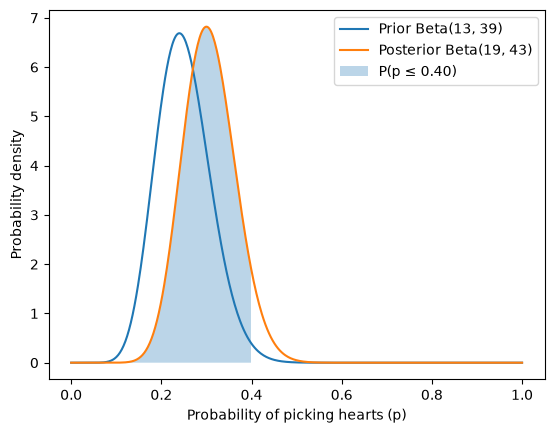

In [11]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 1, 500)
plt.plot(x, beta.pdf(x, alpha_prior, beta_prior), label=f"Prior Beta({alpha_prior}, {beta_prior})")
plt.plot(x, beta.pdf(x, alpha_post, beta_post), label=f"Posterior Beta({alpha_post}, {beta_post})")
plt.fill_between(x, beta.pdf(x, alpha_post, beta_post), where=(x <= 0.4), alpha=0.3, label="P(p ≤ 0.40)")
plt.xlabel("Probability of picking hearts (p)")
plt.ylabel("Probability density")
plt.legend()
plt.show()

# Exercise conversion rates

In [ ]:
#PART A
from scipy.stats import binom, beta

p_old = 0.03       # last year's conversion rate
n = 1000           # visitors tested
buyers = 38        # purchases
non_buyers = n - buyers   # 962

In [ ]:
# PART B
# P(X >= 38) = 1 - P(X <= 37)
prob_a = 1 - binom.cdf(k=buyers - 1, n=n, p=p_old)
print(f"a. P(X >= 38 | p = 3%) = {prob_a:.4f}")

a. P(X >= 38 | p = 3%) = 0.0858


In [ ]:
# PART C
# Prior: belief of ~3% (weak: "3 out of 100")
alpha_prior, beta_prior = 3, 97

# Posterior = prior + data
alpha_post = alpha_prior + buyers        # 41
beta_post  = beta_prior + non_buyers     # 1059
post_mean  = alpha_post / (alpha_post + beta_post)

prob_b = 1 - beta.cdf(0.04, alpha_post, beta_post)

print(f"Posterior: Beta({alpha_post}, {beta_post}), mean = {post_mean:.4f}")
print(f"b. P(conversion rate > 4%) = {prob_b:.4f}")

Posterior: Beta(41, 1059), mean = 0.0373
b. P(conversion rate > 4%) = 0.3031


In [21]:
#Extra optional assignment
a_u, b_u = 1 + buyers, 1 + non_buyers    # Beta(39, 963)
print(f"With Beta(1,1) prior: P(p > 4%) = {1 - beta.cdf(0.04, a_u, b_u):.4f}")

With Beta(1,1) prior: P(p > 4%) = 0.4110


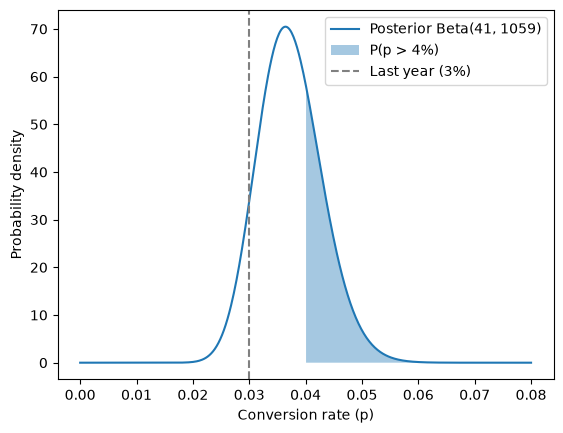

In [ ]:
#Extra optional assignment
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 0.08, 500)
y = beta.pdf(x, alpha_post, beta_post)
plt.plot(x, y, label=f"Posterior Beta({alpha_post}, {beta_post})")
plt.fill_between(x, y, where=(x > 0.04), alpha=0.4, label="P(p > 4%)")
plt.axvline(0.03, linestyle="--", color="grey", label="Last year (3%)")
plt.xlabel("Conversion rate (p)")
plt.ylabel("Probability density")
plt.legend()
plt.show()